In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Baixando o dataset MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
print("Finalizou o processo de baixar o dataset MNIST!")

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.uint8)

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


In [4]:
print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Tipo de X: {X.dtype} | Tipo de y: {y.dtype}")
print(f"Intensidade mínima: {X.min()} | máxima: {X.max()}")
print(f"Classes presentes: {np.unique(y)}")

Formato de X: (70000, 784)
Formato de y: (70000,)
Tipo de X: float32 | Tipo de y: uint8
Intensidade mínima: 0.0 | máxima: 255.0
Classes presentes: [0 1 2 3 4 5 6 7 8 9]


,amostras,percentual
digito,,
0,6903,9.86
1,7877,11.25
2,6990,9.99
3,7141,10.20
4,6824,9.75
5,6313,9.02
6,6876,9.82
7,7293,10.42
8,6825,9.75


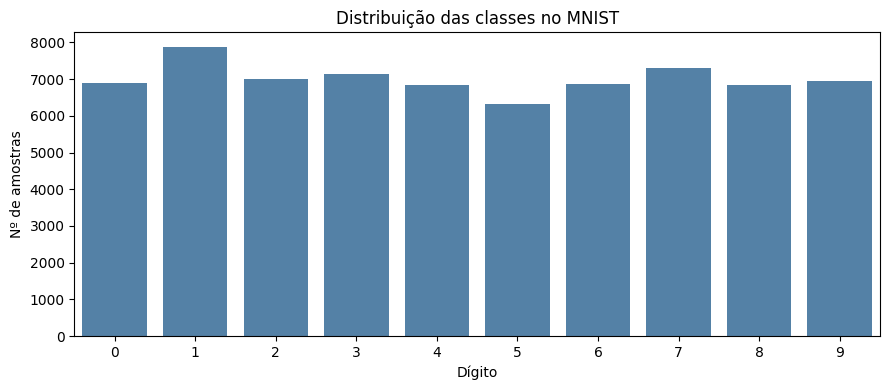

Variação entre a classe mais e a menos frequente: 22.3% da média


In [5]:
contagem = pd.Series(y).value_counts().sort_index()
proporcao = (contagem / len(y) * 100).round(2)

resumo_classes = pd.DataFrame({"amostras": contagem, "percentual": proporcao})
resumo_classes.index.name = "digito"
display(resumo_classes)

plt.figure(figsize=(9, 4))
sns.barplot(x=contagem.index, y=contagem.values, color="steelblue")
plt.title("Distribuição das classes no MNIST")
plt.xlabel("Dígito")
plt.ylabel("Nº de amostras")
plt.tight_layout()
plt.show()

desvio = (contagem.max() - contagem.min()) / contagem.mean() * 100
print(f"Variação entre a classe mais e a menos frequente: {desvio:.1f}% da média")